## Import Library

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
import yaml
import shutil
from tqdm import tqdm
from sklearn.model_selection import train_test_split



## Load Dataset

dataset path

In [2]:
DATASET_PATH = "../data/UECFOODPIX"

TRAIN_IMG = os.path.join(DATASET_PATH, "UECFoodPIX/train/img")
TRAIN_MASK = os.path.join(DATASET_PATH, "UECFoodPIX/train/mask")

TEST_IMG = os.path.join(DATASET_PATH, "UECFoodPIX/test/img")
TEST_MASK = os.path.join(DATASET_PATH, "UECFoodPIX/test/mask")

load category

In [3]:
category_path = os.path.join(DATASET_PATH, "category.txt")

categories = pd.read_csv(
    category_path,
    sep="\t",
    header=0,
    names=["id", "name"]
)

categories.head()

,id,name
0,1,rice
1,2,eels on rice
2,3,pilaf
3,4,chicken-'n'-egg on rice
4,5,pork cutlet on rice


## Sample Dataset

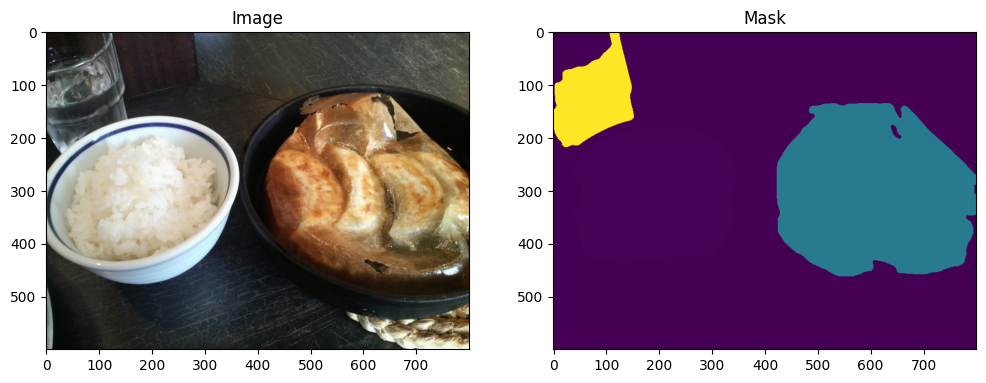

In [4]:
image_path = os.path.join(TRAIN_IMG, "1.jpg")
mask_path = os.path.join(TRAIN_MASK, "1.png")

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path)

mask = mask[:,:,2]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Mask")

plt.show()

unique class

In [5]:
unique_classes = np.unique(mask)

print(unique_classes)

[  0   1  42 102]


## convert to YOLOv8-SEG

folder setup

In [6]:
os.makedirs("../data/dataset_yolo/images/train", exist_ok=True)
os.makedirs("../data/dataset_yolo/images/val", exist_ok=True)

os.makedirs("../data/dataset_yolo/labels/train", exist_ok=True)
os.makedirs("../data/dataset_yolo/labels/val", exist_ok=True)

convert function

In [7]:
def mask_to_yolo(mask_path, output_txt_path):

    mask = cv2.imread(mask_path)
    mask = mask[:,:,2]

    h, w = mask.shape

    lines = []

    unique_classes = np.unique(mask)

    for class_id in unique_classes:

        if class_id == 0:
            continue

        binary_mask = np.uint8(mask == class_id)

        contours, _ = cv2.findContours(
            binary_mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        for contour in contours:

            if len(contour) < 3:
                continue

            contour = contour.squeeze()

            if len(contour.shape) != 2:
                continue

            polygon = []

            for point in contour:
                x = point[0] / w
                y = point[1] / h

                polygon.extend([x, y])

            line = f"{class_id - 1} " + " ".join(
                map(str, polygon)
            )

            lines.append(line)

    with open(output_txt_path, "w") as f:
        f.write("\n".join(lines))

convert all dataset to YOLO format

In [8]:
image_files = os.listdir(TRAIN_IMG)

for image_name in tqdm(image_files):

    image_id = Path(image_name).stem

    img_path = os.path.join(TRAIN_IMG, image_name)
    mask_path = os.path.join(TRAIN_MASK, f"{image_id}.png")

    # copy image
    shutil.copy(
        img_path,
        f"../data/dataset_yolo/images/train/{image_name}"
    )

    # convert label
    output_txt = f"../data/dataset_yolo/labels/train/{image_id}.txt"

    mask_to_yolo(mask_path, output_txt)

100%|██████████| 9000/9000 [01:00<00:00, 149.08it/s]


## Split Dataset

In [9]:
all_images = os.listdir("../data/dataset_yolo/images/train")

train_imgs, val_imgs = train_test_split(
    all_images,
    test_size=0.2,
    random_state=42
)

make validation dataset

In [10]:
for img_name in val_imgs:

    image_id = Path(img_name).stem

    shutil.move(
        f"../data/dataset_yolo/images/train/{img_name}",
        f"../data/dataset_yolo/images/val/{img_name}"
    )

    shutil.move(
        f"../data/dataset_yolo/labels/train/{image_id}.txt",
        f"../data/dataset_yolo/labels/val/{image_id}.txt"
    )

generate class yaml for modelling

In [11]:

names_dict = {}

for _, row in categories.iterrows():
    names_dict[int(row["id"]) - 1] = row["name"]

yaml_data = {
    "path": "../data/dataset_yolo",
    "train": "images/train",
    "val": "images/val",
    "names": names_dict
}

with open("food.yaml", "w") as f:
    yaml.dump(
        yaml_data,
        f,
        sort_keys=False,
        allow_unicode=True
    )

print("food.yaml berhasil dibuat")

food.yaml berhasil dibuat
